In [1]:
!pip install langgraph
!pip install langchain
!pip install langgraph_openai

ERROR: Could not find a version that satisfies the requirement langgraph_openai (from versions: none)
ERROR: No matching distribution found for langgraph_openai


In [2]:
!pip install dotenv
 

In [ ]:
from langgraph.graph import StateGraph, START, END

In [4]:
from typing import TypedDict
class BMIState(TypedDict):
    weight_kg : float
    height_m : float
    bmi : float
    category: str
     

In [5]:
def calculate_bmi(state: BMIState)->BMIState :
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight/(height**2)
    state['bmi'] = round(bmi, 2)
    return state



In [6]:
def label_bmi(state: BMIState)->BMIState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = "Underweight"
    elif 18.5 <= 25.5:
        state['category'] = "Normal"
    else :
        state['category'] = "overwieght"
    return state

In [7]:
graph = StateGraph(BMIState)


#add nodes to graph
graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node("label_bmi", label_bmi)
#add edges to graph
graph.add_edge(START,'calculate_bmi')
graph.add_edge("calculate_bmi", "label_bmi")
graph.add_edge('label_bmi',END)
#compile the graph
workflow = graph.compile()
#execute
final_state = workflow.invoke({'weight_kg':80, 'height_m':1.73})
print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Normal'}


In [8]:
!pip install langchain_openai

  Using cached langchain_openai-1.1.11-py3-none-any.whl.metadata (3.1 kB)
  Using cached langchain_core-1.2.19-py3-none-any.whl.metadata (4.4 kB)
  Using cached openai-2.28.0-py3-none-any.whl.metadata (29 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
Using cached langchain_openai-1.1.11-py3-none-any.whl (87 kB)
Using cached langchain_core-1.2.19-py3-none-any.whl (503 kB)
Using cached openai-2.28.0-py3-none-any.whl (1.1 MB)
Using cached distro-1.9.0-py3-none-any.whl (20 kB)

   ---------------- ----------------------- 2/5 [openai]
   ---------------- ----------------------- 2/5 [openai]
   ---------------- ----------------------- 2/5 [openai]
   ---------------- ----------------------- 2/5 [openai]
   ---------------- ----------------------- 2/5 [openai]
   ---------------- ----------------------- 2/5 [openai]
   ---------------- ----------------------- 2/5 [openai]
   ---------------- ----------------------- 2/5 [openai]
   ---------------- ----------------------- 

In [9]:
from langchain_openai import ChatOpenAI

In [12]:
from dotenv import load_dotenv
load_dotenv()
model = ChatOpenAI()

In [ ]:
class BlogState(TypedDict):
    title: str
    outline: str
    content: str

In [ ]:
def create_outline(state:BlogState) -> BlogState:
    #fetch title
    title = state['title']
    #call llm
    prompt = f"Generate a detailed outline for a blog on the topic - {title}"
    outline = model.invoke(prompt).content
    #update state
    state['outline'] = outline
    return state


In [ ]:
graph = StateGraph(BlogState)
#nodes
graph.add_node("create_outline", create_outline)


In [2]:

from langgraph.graph import StateGraph, START,END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict
from pydantic import BaseModel, Field

In [5]:
load_dotenv()

True

In [6]:
model = ChatOpenAI(model = 'gpt-4o-mini')

In [7]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description='Detailed feedback for essay')
    score:int = Field(description='Score out of 10',ge=0, le=10)

In [11]:
structured_model = model.with_structured_output(EvaluationSchema)

In [20]:
essay = """"Artificial Intelligence (AI) has become a cornerstone of India’s digital transformation, reshaping industries and public services. The Government of India has launched the IndiaAI Mission, allocating significant resources to build infrastructure, skill talent, and promote ethical AI adoption. With investments exceeding ₹10,300 crore and access to 38,000 GPUs, India is positioning itself as a leader in inclusive innovation. 

India’s role in AI extends beyond economic growth. In healthcare, AI-powered diagnostics are improving access in rural areas, while in agriculture, predictive models help farmers make informed crop decisions. The National Strategy for AI by NITI Aayog highlights focus areas such as smart cities, education, and governance, ensuring that AI benefits citizens at every level. 
"""

In [21]:
prompt = f"Evaluate the language quality of the following essay and provide a feedback and assingn a score out of 10 \n {essay}"
structured_model.invoke(prompt)

RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [25]:
# For Python 3.9+
from typing import Annotated

In [ ]:
class UPSC(TypedDict):
    essay: str
    language_feedback:str
    analysis_feedback:str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]  
    avg_score:float

In [ ]:
def evaluate_language(state:UPSC):
  prompt =  f"Evaluate the language quality of the following essay and provide a feedback and assingn a score out of 10 \n {state['essay']}"
  output = structured_model.invoke(prompt)
  return {'language_feedback':output.feedback, 'individual_scores':output.scores}

In [29]:
def evaluate_analysis(state:UPSC):
  prompt =  f"Evaluate the  depth of analysis of the following essay and provide a feedback and assingn a score out of 10 \n {state['essay']}"
  output = structured_model.invoke(prompt)
  return {'language_analysis':output.feedback, 'individual_scores':output.scores}

In [ ]:
def evaluate_thought(state:UPSC):
  prompt =  f"Evaluate the clarity of the thought of the following essay and provide a feedback and assingn a score out of 10 \n {state['essay']}"
  output = structured_model.invoke(prompt)
  return {'language_feedback':output.feedback, 'individual_scores':output.scores}

In [ ]:
graph = StateGraph(UPSC)
graph.add_node('evaluate_language', evaluate_language)

In [44]:
class quad(TypedDict):
    a:int
    b:int
    c:int
    equation:str
    discriminant:float
    result:str

In [11]:
def show_equation (state: quad):
 equation = f'{state["a"]}x2{state["b"]}x{state["c"]}'
 return {"equation": equation}


In [47]:
def cal_dis(state:quad):
    discriminant = state['b'] **2 - (4*state['a'] * state['c'])
    return {"discriminant": discriminant}

def real_roots(state:quad):
   root1 = (-state['b'] + state['discriminant']**0.5)/(2*state['a'])
   root2 =  (-state['b'] - state['discriminant']**0.5)/(2*state['a'])

   result = f'the real roots are {root1} and {root2}'
   return{'result':result}

In [48]:
def repeated_roots(state:quad):
   root = (-state['b']/2*state['a'])
   

   result = f'the repeating root is {root} '
   return{'result':result}

def no_real_roots(state:quad):
  

   result = "no real roots"
   return{'result':result}

In [49]:
from typing import Literal
def check_condition(state:quad) -> Literal["real_roots", "repeated_roots", "no_real_roots"]:
    if state["discriminant"] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "repeated_roots"
    else: 
        return "no_real_roots"

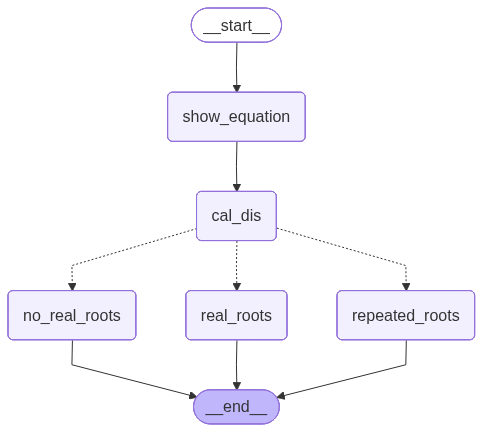

In [50]:
graph = StateGraph(quad)
graph.add_node("show_equation",show_equation)

graph.add_node("cal_dis",cal_dis)
graph.add_node("real_roots", real_roots)
graph.add_node("repeated_roots", repeated_roots)
graph.add_node("no_real_roots",no_real_roots)





# ADD Edeges
graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "cal_dis")
graph.add_conditional_edges("cal_dis", check_condition )
graph.add_edge("real_roots", END)
graph.add_edge("repeated_roots", END)
graph.add_edge("no_real_roots", END)
workflow = graph.compile()
workflow

In [80]:
# intitial_state ={
    "a": 4,
    "b" : -5,
    "c" : -4
}
workflow.invoke(intitial_state)

IndentationError: unexpected indent (1832080837.py, line 2)

In [79]:

load_dotenv()
model = ChatOpenAI(model = "gpt-4o-mini")

In [98]:
class sentimentschema(BaseModel):
    sentiment: Literal["positive", "negative"] =  Field(description="sentiment of the review")

In [71]:
structured_model = model.with_structured_output(sentimentschema)
 

In [72]:
class reviewstate(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response :str

In [92]:
def find_sentiment(state: reviewstate):
    review_text = state.get("review")
    if not review_text:
        raise ValueError("State must contain a 'review' key with text")
    prompt = f'for the following review find out the sentiment \n {review_text}'
    sentiment = structured_model.invoke(prompt).sentiment
    return {"sentiment": sentiment}


In [93]:
graph = StateGraph(TypedDict)  
graph.add_node("find_sentiment", find_sentiment)
graph.add_edge(START, "find_sentiment")
graph.add_edge("find_sentiment", END)
workflow = graph.compile()

c:\Users\GURJOT SINGH\miniconda3\envs\llm_scratch\lib\site-packages\langgraph\graph\state.py:99: UserWarning: Invalid state_schema: <function TypedDict at 0x000002476C0DD510>. Expected a type or Annotated[type, reducer]. Please provide a valid schema to ensure correct updates.
 See: https://langchain-ai.github.io/langgraph/reference/graphs/#stategraph
  warnings.warn(


In [97]:
initial_state1 = {"review": "The product was excellent and delivery was fast"}
workflow.invoke(initial_state1)


ValueError: State must contain a 'review' key with text

In [95]:
workflow.invoke(intitial_state1)

ValueError: State must contain a 'review' key with text

In [99]:
from typing import Literal, TypedDict
from pydantic import BaseModel, Field

# Schema for model output
class sentimentschema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="sentiment of the review")

structured_model = model.with_structured_output(sentimentschema)

# State schema
class reviewstate(TypedDict):
    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict | None
    response: str | None

# Node function
def find_sentiment(state: reviewstate):
    review_text = state.get("review")
    if not review_text:
        raise ValueError("State must contain a 'review' key with text")
    prompt = f'for the following review find out the sentiment \n {review_text}'
    sentiment = structured_model.invoke(prompt).sentiment
    return {"sentiment": sentiment}

# Build graph
graph = StateGraph(reviewstate)
graph.add_node("find_sentiment", find_sentiment)
graph.add_edge(START, "find_sentiment")
graph.add_edge("find_sentiment", END)

workflow = graph.compile()

# Correct variable name
initial_state1 = {"review": "The product was excellent and delivery was fast"}
workflow.invoke(initial_state1)


RateLimitError: Error code: 429 - {'error': {'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, read the docs: https://platform.openai.com/docs/guides/error-codes/api-errors.', 'type': 'insufficient_quota', 'param': None, 'code': 'insufficient_quota'}}

In [100]:
def check_sentiment(state: reviewstate):
    if state["sentiment"] == "positive":
        return "positive_response"
    else: 
        return "run_diagnosis"